In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [83]:
df=pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\prac\Data04_Employee_Attrition.csv')

In [84]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [85]:
df['Department'].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [86]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['salary']=le.fit_transform(df['salary'])
from sklearn.model_selection import train_test_split

In [87]:
from tensorflow import keras
from keras.layers import Dense,Input,Dropout
from keras.models import Sequential


In [88]:
df=pd.get_dummies(df,drop_first=True)

In [89]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,1,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,2,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,2,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,1,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,1,False,False,False,False,False,False,True,False,False


In [90]:
df=df.astype(int)

In [91]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0,0,2,157,3,0,1,0,1,0,0,0,0,0,0,1,0,0
1,0,0,5,262,6,0,1,0,2,0,0,0,0,0,0,1,0,0
2,0,0,7,272,4,0,1,0,2,0,0,0,0,0,0,1,0,0
3,0,0,5,223,5,0,1,0,1,0,0,0,0,0,0,1,0,0
4,0,0,2,159,3,0,1,0,1,0,0,0,0,0,0,1,0,0


In [92]:
df['salary'].value_counts()

salary
1    7316
2    6446
0    1237
Name: count, dtype: int64

In [93]:
df.shape

(14999, 18)

In [94]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'salary', 'Department_RandD',
       'Department_accounting', 'Department_hr', 'Department_management',
       'Department_marketing', 'Department_product_mng', 'Department_sales',
       'Department_support', 'Department_technical'],
      dtype='object')

In [95]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
count,14999.00000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.00740,0.018868,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,1.347290,0.052470,0.051137,0.049270,0.042003,0.057204,0.060137,0.276018,0.148610,0.181345
std,0.08571,0.136063,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,0.625819,0.222981,0.220284,0.216438,0.200602,0.232239,0.237749,0.447041,0.355715,0.385317
min,0.00000,0.000000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,0.000000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.00000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [96]:
df_num=df.select_dtypes(include='number').columns.to_list()
df_col=df.select_dtypes(include='object').columns.to_list()

In [97]:
df_col

[]

In [98]:
df['Work_accident'].value_counts()

Work_accident
0    12830
1     2169
Name: count, dtype: int64

In [99]:
df['number_project'].value_counts(normalize=True)

number_project
4    0.291019
3    0.270351
5    0.184079
2    0.159211
6    0.078272
7    0.017068
Name: proportion, dtype: float64

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   satisfaction_level      14999 non-null  int64
 1   last_evaluation         14999 non-null  int64
 2   number_project          14999 non-null  int64
 3   average_montly_hours    14999 non-null  int64
 4   time_spend_company      14999 non-null  int64
 5   Work_accident           14999 non-null  int64
 6   left                    14999 non-null  int64
 7   promotion_last_5years   14999 non-null  int64
 8   salary                  14999 non-null  int64
 9   Department_RandD        14999 non-null  int64
 10  Department_accounting   14999 non-null  int64
 11  Department_hr           14999 non-null  int64
 12  Department_management   14999 non-null  int64
 13  Department_marketing    14999 non-null  int64
 14  Department_product_mng  14999 non-null  int64
 15  Department_sales   

In [101]:
df.duplicated().sum()

np.int64(4491)

In [102]:
import seaborn as sns

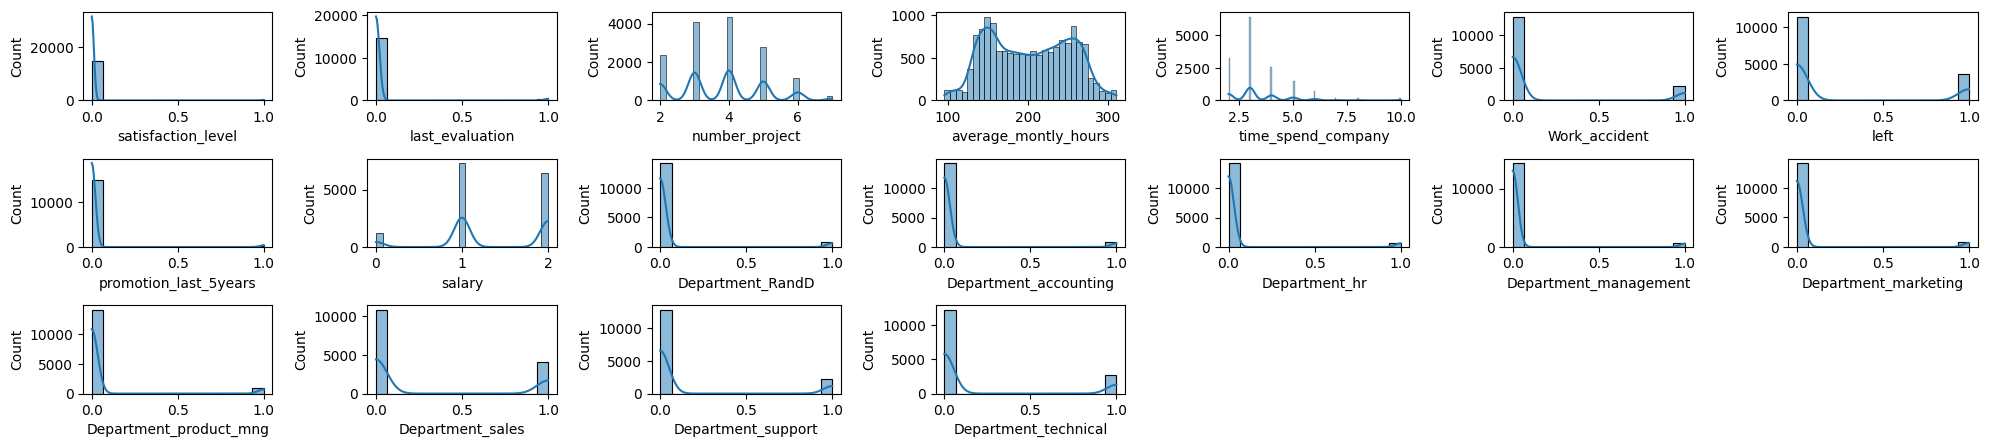

In [103]:
plt.figure(figsize=(20,10))
for index,columns in enumerate(df_num):
   
    plt.subplot(7,7,index+1)
    sns.histplot(df[columns],kde=True)
    
plt.tight_layout()

<Axes: >

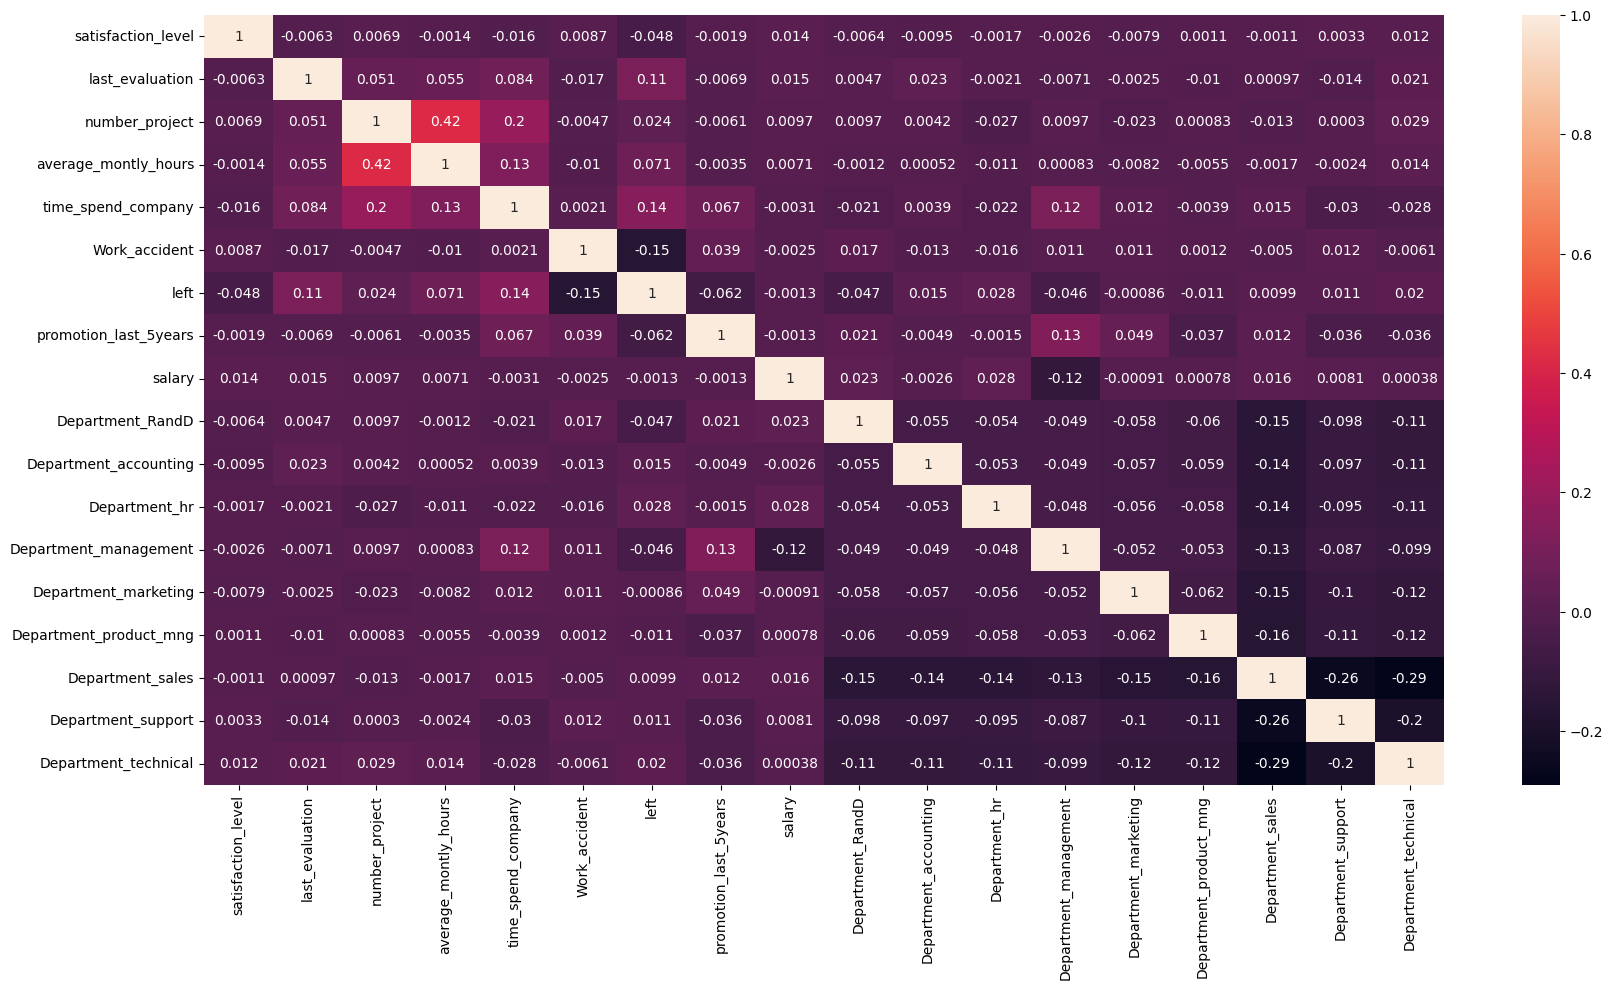

In [104]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)

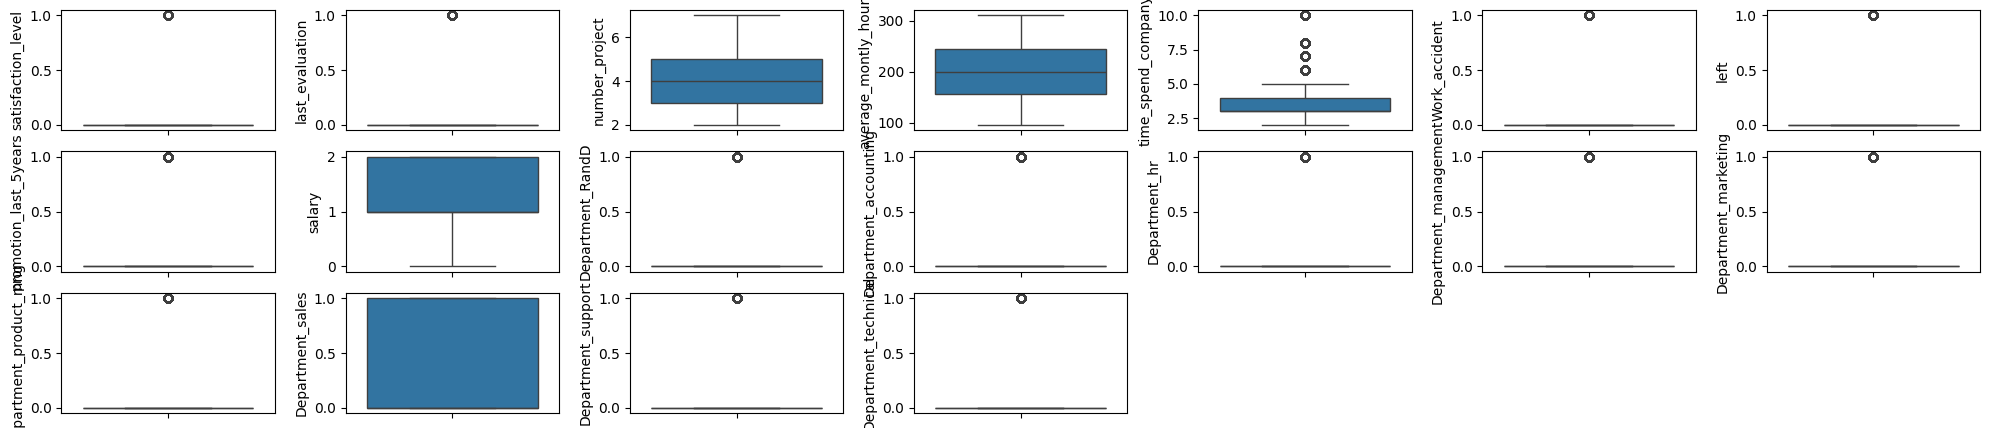

In [105]:
plt.figure(figsize=(20,10))
for index,columns in enumerate(df_num):
   
    plt.subplot(7,7,index+1)
    sns.boxplot(df[columns])
    
plt.tight_layout()

In [106]:
df=df.drop_duplicates()

In [107]:
x=df.drop('left',axis=1)
y=df['left']


In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [109]:
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0,0,2,157,3,0,0,1,0,0,0,0,0,0,1,0,0
1,0,0,5,262,6,0,0,2,0,0,0,0,0,0,1,0,0
2,0,0,7,272,4,0,0,2,0,0,0,0,0,0,1,0,0
3,0,0,5,223,5,0,0,1,0,0,0,0,0,0,1,0,0
4,0,0,2,159,3,0,0,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0,0,3,259,10,1,1,0,0,0,0,1,0,0,0,0,0
11996,0,0,5,266,10,0,1,0,0,0,0,1,0,0,0,0,0
11997,0,0,3,185,10,0,1,0,0,0,0,1,0,0,0,0,0
11998,0,0,3,172,10,0,1,0,0,0,0,0,1,0,0,0,0


In [110]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
sc=StandardScaler()
x_train_scaler=sc.fit_transform(x_train)
x_test_scaler=sc.transform(x_test)

In [111]:
x_train_scaler

array([[-0.09986173, -0.14062131,  0.11069899, ..., -0.57670923,
        -0.41735637,  2.11486554],
       [-0.09986173, -0.14062131, -0.75090817, ..., -0.57670923,
         2.39603388, -0.4728433 ],
       [-0.09986173, -0.14062131, -0.75090817, ..., -0.57670923,
        -0.41735637,  2.11486554],
       ...,
       [-0.09986173, -0.14062131,  0.11069899, ..., -0.57670923,
        -0.41735637, -0.4728433 ],
       [-0.09986173, -0.14062131,  0.11069899, ..., -0.57670923,
        -0.41735637, -0.4728433 ],
       [-0.09986173, -0.14062131,  0.97230615, ..., -0.57670923,
        -0.41735637,  2.11486554]], shape=(8406, 17))

In [112]:
x_train

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
2029,0,0,4,262,4,0,0,1,0,0,0,0,0,0,0,0,1
10810,0,0,3,260,4,0,0,1,0,0,0,0,0,0,0,1,0
9663,0,0,3,274,2,0,0,0,0,0,0,0,0,0,0,0,1
10316,0,0,5,171,3,0,0,2,0,0,0,0,0,0,1,0,0
9268,0,0,6,196,2,0,0,2,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4660,0,0,4,274,2,0,0,2,0,0,0,0,0,0,0,0,1
7644,0,0,2,269,2,1,0,2,0,0,0,0,0,0,1,0,0
11403,0,0,4,220,3,0,1,2,0,0,0,1,0,0,0,0,0
1439,0,0,4,253,5,1,0,2,0,0,0,0,0,0,0,0,0


In [113]:
model=Sequential()
model.add(Input(shape=(17,)))
model.add(Dense(9,activation='relu',kernel_initializer='uniform'))
model.add(Dense(1,activation='sigmoid'))


In [114]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 9)              │           162 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172 (688.00 B)

 Trainable params: 172 (688.00 B)

 Non-trainable params: 0 (0.00 B)

In [115]:




model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [116]:
from keras.callbacks import EarlyStopping

In [117]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [118]:
x_train_scaler.shape

(8406, 17)

Total training samples ÷ Batch size = Number of batches
8406/32=262.6==263

In [119]:
history=model.fit(x_train_scaler,y_train,validation_data=(x_test_scaler,y_test),epochs=100,batch_size=32,callbacks=[early_stop])

Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8508 - loss: 0.4925 - val_accuracy: 0.8578 - val_loss: 0.3868
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8706 - loss: 0.3486 - val_accuracy: 0.8758 - val_loss: 0.3464
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8800 - loss: 0.3155 - val_accuracy: 0.8849 - val_loss: 0.3182
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8872 - loss: 0.2906 - val_accuracy: 0.8849 - val_loss: 0.2978
Epoch 5/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8890 - loss: 0.2741 - val_accuracy: 0.8877 - val_loss: 0.2836
Epoch 6/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8895 - loss: 0.2618 - val_accuracy: 0.8882 - val_loss: 0.2708
Epoch 7/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8928 - loss: 0.2521 - val_accuracy: 0.8901 - val_loss: 0.2607
Epoch 8/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8945 - loss: 0.2446 - val_accu

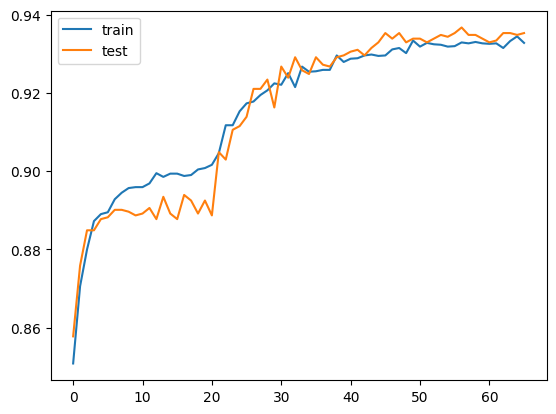

In [120]:
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

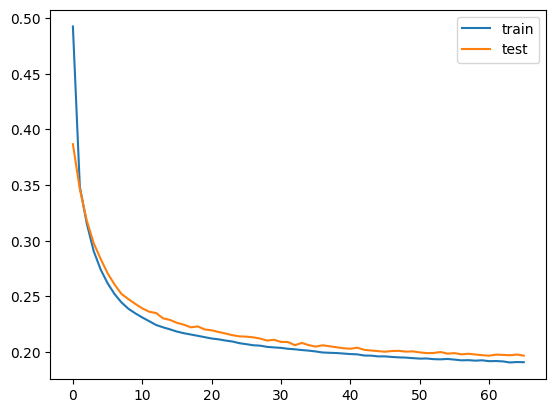

In [121]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

In [122]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
y_pred=model.predict(x_test_scaler)
y_pred=(y_pred>0.5)
y_pred

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]], shape=(2102, 1))

In [123]:
accuracy_score(y_test,y_pred)

0.9329210275927687

In [124]:
confusion_matrix(y_test,y_pred)

array([[1738,   53],
       [  88,  223]])

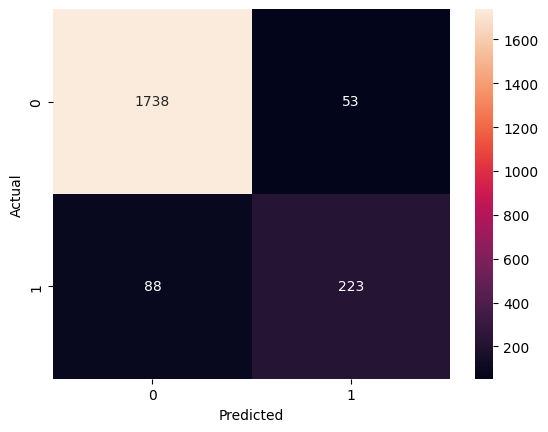

In [125]:
cb = confusion_matrix(y_test,y_pred)
sns.heatmap(cb,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [129]:
import scikeras
scikeras.__version__

'0.13.0'

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1791
           1       0.79      0.74      0.76       311

    accuracy                           0.93      2102
   macro avg       0.87      0.85      0.86      2102
weighted avg       0.93      0.93      0.93      2102



In [ ]:
#imporving acc

from sklearn.model_selection import StratifiedKFold,cross_val_score
def build_classifier():
    model=Sequential()
    model.add(Input(shape=(17,)))
    model.add(Dense(9,activation='relu',kernel_initializer='uniform'))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model
from scikeras.wrappers import KerasClassifier
classifier = KerasClassifier(build_fn=build_classifier,epochs=50,batch_size=32)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_val_score(classifier, x_train_scaler, y_train, cv=kfold)
print("Cross-validation accuracy scores:", results)
print("Mean cross-validation accuracy:", results.mean())


Epoch 1/50


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7940 - loss: 0.6124
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8724 - loss: 0.4511
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8737 - loss: 0.3785
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8785 - loss: 0.3496
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8841 - loss: 0.3321
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8855 - loss: 0.3188
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8873 - loss: 0.3074
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8895 - loss: 0.2984
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8895 - loss: 0.2898
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8914 - loss: 0.2817
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8899 - loss: 0.2749
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8211 - loss: 0.5570
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8555 - loss: 0.4099
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8659 - loss: 0.3579
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8766 - loss: 0.3182
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8813 - loss: 0.2852
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8855 - loss: 0.2665
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8865 - loss: 0.2548
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8862 - loss: 0.2478
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8906 - loss: 0.2423
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8898 - loss: 0.2387
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8917 - loss: 0.2360
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

...

211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8296 - loss: 0.5632
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8641 - loss: 0.4083
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8760 - loss: 0.3575
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.3314
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8825 - loss: 0.3095
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8830 - loss: 0.2949
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8852 - loss: 0.2845
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8852 - loss: 0.2769
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8857 - loss: 0.2709
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8870 - loss: 0.2651
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8897 - loss: 0.2603
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8384 - loss: 0.5353
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8694 - loss: 0.3773
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8800 - loss: 0.3340
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8831 - loss: 0.3104
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8864 - loss: 0.2927
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8871 - loss: 0.2792
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8894 - loss: 0.2675
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8906 - loss: 0.2573
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8912 - loss: 0.2502
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8931 - loss: 0.2434
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8958 - loss: 0.2370
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8288 - loss: 0.5745
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8703 - loss: 0.3954
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8784 - loss: 0.3364
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8843 - loss: 0.3121
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8880 - loss: 0.2962
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8873 - loss: 0.2832
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8894 - loss: 0.2738
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8888 - loss: 0.2661
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8895 - loss: 0.2602
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8916 - loss: 0.2553
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8909 - loss: 0.2509
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [131]:
results.var()

np.float64(2.8509169898297905e-05)

DROPOUT LAYER

In [149]:
model2=Sequential()
model2.add(Dense(9,activation='relu',kernel_initializer='uniform',input_dim=17))
model2.add(Dropout(0.2))


model2.add(Dense(1,activation='sigmoid'))

In [150]:
model2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 9)              │           162 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172 (688.00 B)

 Trainable params: 172 (688.00 B)

 Non-trainable params: 0 (0.00 B)

In [151]:
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model2.fit(x_train_scaler,y_train,validation_data=(x_test_scaler,y_test),epochs=50,batch_size=32,callbacks=[early_stop])

Epoch 1/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8507 - loss: 0.4797 - val_accuracy: 0.8563 - val_loss: 0.3934
Epoch 2/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8639 - loss: 0.3729 - val_accuracy: 0.8630 - val_loss: 0.3558
Epoch 3/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8713 - loss: 0.3405 - val_accuracy: 0.8782 - val_loss: 0.3226
Epoch 4/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8749 - loss: 0.3166 - val_accuracy: 0.8787 - val_loss: 0.2947
Epoch 5/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8796 - loss: 0.2996 - val_accuracy: 0.8873 - val_loss: 0.2764


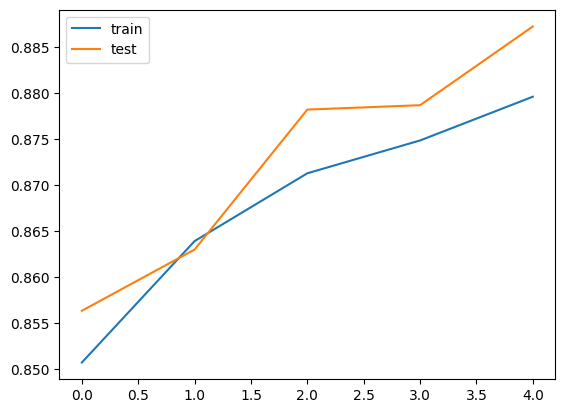

In [154]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()

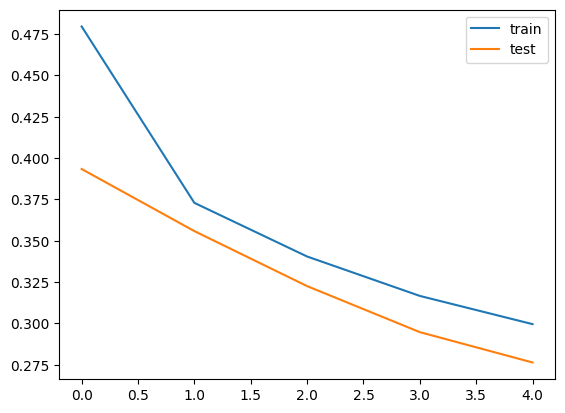

In [155]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()

In [ ]:
y_pred2=model2.predict(x_test_scaler)
y_pred2=(y_pred2>0.5)
accuracy_score(y_test,y_pred2)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.8587059942911512

In [170]:
from sklearn.model_selection import GridSearchCV
def build_classifier1(optimizer='adam'):
    model=Sequential()
    model.add(Input(shape=(17,)))
    model.add(Dense(9,activation='relu',kernel_initializer='uniform'))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [171]:
model=KerasClassifier(model=build_classifier1)
params={'optimizer':['adam','rmsprop']}

In [172]:
gird=GridSearchCV(estimator=model,param_grid=params,cv=5,scoring='accuracy')
grid_result = gird.fit(x_train_scaler, y_train)
print("best parameters: ",grid_result.best_params_)
print("best accyuracy: ",grid_result.best_score_)


211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8560 - loss: 0.5070
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8217 - loss: 0.5668
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8146 - loss: 0.5687
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8509 - loss: 0.5151
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8168 - loss: 0.5787
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8125 - loss: 0.5830
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8217 - loss: 0.5729
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8471 - loss: 0.4813
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8440 - loss: 0.5304
53/53 ━━━━━━━